powerball_ticket_florida

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import statsmodels.api as sm 

import os
os.getcwd()
os.chdir("/Users/xiaolingsundberg/Desktop/Other Data Analysis Projects (for fun)/CovidOnLottery/Data")

# Read in data and Sanity Check

In [3]:
# read in data - excel
df = pd.read_excel("powerball_tickets_fl.xlsx")
print(df.head())
print(df.tail())
print(df.shape)
print(df.columns)
print(df.dtypes)

   draw_date  winners  jackpot  covid  covid_cases  monday  wednesday  \
0 2016-05-04    77588      348      0            0       0          1   
1 2016-05-07   134145      415      0            0       0          0   
2 2016-05-11    23019       40      0            0       0          1   
3 2016-05-14    29783       50      0            0       0          0   
4 2016-05-18    27506       60      0            0       0          1   

   unempr_a  unempr  jan  ...  sept  oct  nov  year2016  year2017  year2018  \
0       4.9     4.6    0  ...     0    0    0         1         0         0   
1       4.9     4.6    0  ...     0    0    0         1         0         0   
2       4.9     4.6    0  ...     0    0    0         1         0         0   
3       4.9     4.6    0  ...     0    0    0         1         0         0   
4       4.9     4.6    0  ...     0    0    0         1         0         0   

   year2019  year2020  year2021  year2022  
0         0         0         0         0 

In [4]:
print(df.isnull().sum())

draw_date      0
winners        0
jackpot        0
covid          0
covid_cases    0
monday         0
wednesday      0
unempr_a       0
unempr         0
jan            0
feb            0
mar            0
apr            0
may            0
jun            0
jul            0
aug            0
sept           0
oct            0
nov            0
year2016       0
year2017       0
year2018       0
year2019       0
year2020       0
year2021       0
year2022       0
dtype: int64


Conclusion: The dataset has 639 rows and 27 columns. All variables are in integer format except for the unempr and unempr_adjusted (float). There are no missing values.

# Data Exploration 
## Summary Statistics and Visualization 

In [5]:
# summary statistics 
print(df.describe())

                           draw_date        winners     jackpot       covid  \
count                            639     639.000000  639.000000  639.000000   
mean   2019-05-18 11:58:52.394366208   34147.276995  168.948357    0.374022   
min              2016-05-04 00:00:00   10149.000000   20.000000    0.000000   
25%              2017-11-13 00:00:00   21715.500000   70.000000    0.000000   
50%              2019-05-25 00:00:00   27096.000000  130.000000    0.000000   
75%              2020-12-03 12:00:00   34332.000000  229.000000    1.000000   
max              2022-03-07 00:00:00  378460.000000  750.000000    1.000000   
std                              NaN   30019.941716  132.861274    0.484248   

        covid_cases      monday   wednesday    unempr_a      unempr  \
count    639.000000  639.000000  639.000000  639.000000  639.000000   
mean    3197.406886    0.043818    0.474178    4.733959    4.718936   
min        0.000000    0.000000    0.000000    2.700000    2.500000   
25% 

Notes: tickets sold is generated based on the last prize probability which is 1/38.32. 
Expected winner = tickets sold * probability of winning -> ticket sold = winner / (1/38.32) = winners*38.32

In [6]:
df["tickets_sold"] = df["winners"]*38.32
print(df["tickets_sold"].head()) 

0    2973172.16
1    5140436.40
2     882088.08
3    1141284.56
4    1054029.92
Name: tickets_sold, dtype: float64


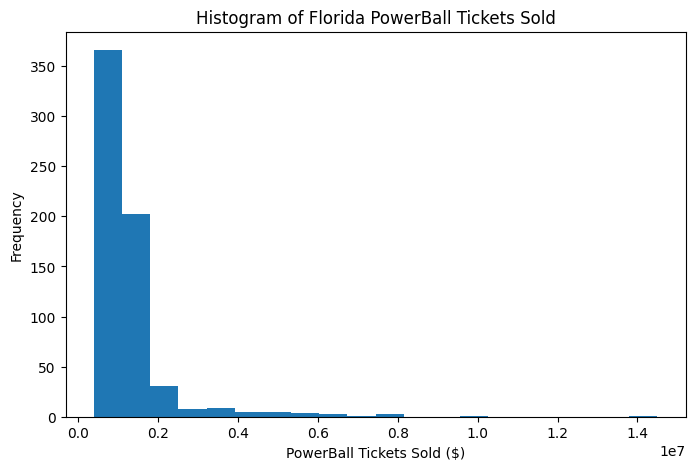

In [8]:
# histogram of tickets_sold 
plt.figure(figsize=(8,5))
plt.hist(df["tickets_sold"],bins=20)
plt.xlabel("PowerBall Tickets Sold ($)")
plt.ylabel("Frequency")
plt.title("Histogram of Florida PowerBall Tickets Sold")
plt.show()